<a href="https://colab.research.google.com/github/Yennybel01/ALGORITMOS-GENETICOS-EN-MACHINE-LEARNING/blob/main/Actividad_03_AGNeuroevolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neuroevolution
## Dataset: Mushroom Classification (UCI / Kaggle)

---
### Se realizara:
- Cargar y preparar el dataset
- Normalizar los datos
- Construir la red neuronal (MLP) como función parametrizable
- Definir cómo se entrena y cómo se evalúa

---

In [ ]:
!pip install pandas scikit-learn numpy matplotlib -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✓ Librerías cargadas')

✓ Librerías cargadas


---
## Cargar el Dataset

El dataset **Mushroom Classification** tiene:
- **8,124 hongos** descritos con 22 características categóricas
- **Objetivo:** predecir si el hongo es `p` (venenoso) o `e` (comestible)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

ruta = '/content/drive/MyDrive/noveno/mushrooms.csv'
df = pd.read_csv(ruta)

print('✓ Dataset cargado desde Google Drive')
print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head(3)

✓ Dataset cargado desde Google Drive
Shape: (8124, 23)
Columnas: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m


---
## Preprocesamiento: dataset → X, y

In [ ]:
# Codificar variables categóricas
le = LabelEncoder()
df_enc = df.copy()

for col in df_enc.columns:
    if df_enc[col].dtype == 'object':
        df_enc[col] = le.fit_transform(df_enc[col])

# Separar features y etiqueta
target_col = df_enc.columns[0]
X = df_enc.drop(columns=[target_col]).values.astype(float)
y = df_enc[target_col].values

print(f'X shape : {X.shape}   (muestras × features)')
print(f'y shape : {y.shape}')
print(f'Clases  : {np.unique(y)}  →  0 = comestible, 1 = venenoso')
print(f'Balance : {np.bincount(y)}  ({np.bincount(y)/len(y)*100}%)')

X shape : (8124, 22)   (muestras × features)
y shape : (8124,)
Clases  : [0 1]  →  0 = comestible, 1 = venenoso
Balance : [4208 3916]  ([51.79714426 48.20285574]%)


Se cargó un dataset desde Google Drive con 8124 registros y 23 variables, todas de tipo categórico, incluyendo class como variable objetivo (comestible o venenoso). Debido a que los modelos requieren datos numéricos, se aplicó LabelEncoder a todas las columnas, transformando cada categoría en valores enteros. Luego, se separaron las variables en X (22 características) y y (etiqueta), obteniendo dimensiones X = (8124, 22) y y = (8124,). Las clases resultantes fueron 0 (comestible) y 1 (venenoso), con una distribución balanceada de aproximadamente 51.8% y 48.2%, respectivamente, dejando el dataset listo para entrenamiento de modelos de clasificación.

---
## Normalización

Las redes neuronales son sensibles a la escala de los datos.  
Usamos **StandardScaler**: convierte cada feature a media=0 y desviación estándar=1.



In [ ]:
# Normalización
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# Verificar
print(f'Media antes  : {X[:, 0].mean():.3f}   →   después: {X_norm[:, 0].mean():.6f}')
print(f'Std antes    : {X[:, 0].std():.3f}   →   después: {X_norm[:, 0].std():.6f}')
print('✓ Datos normalizados')

# División train/test para evaluación final
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')

Media antes  : 3.348   →   después: 0.000000
Std antes    : 1.604   →   después: 1.000000
✓ Datos normalizados
Train: 6499 muestras | Test: 1625 muestras


Se aplicó una normalización a las variables de entrada (X) utilizando StandardScaler, transformando los datos para que tengan media 0 y desviación estándar 1, lo cual mejora el rendimiento de muchos modelos de aprendizaje automático. Esto se verifica al observar que una característica pasó de tener media 3.348 y desviación estándar 1.604 a valores cercanos a 0 y 1, respectivamente. Posteriormente, el dataset fue dividido en conjuntos de entrenamiento y prueba usando train_test_split, con un 80% de los datos para entrenamiento (6499 muestras) y 20% para prueba (1625 muestras), manteniendo el balance de clases mediante estratificación.

---
## Función que crea la Red Neuronal

La red neuronal es un **MLP (Multilayer Perceptron)**.

```
Entrada (22) → [Capa oculta 1] → [Capa oculta 2?] → Salida (2 clases)
```

### Parámetros que puede cambiar el AG:
| Parámetro | Descripción |
|---|---|
| `capas_ocultas` | Tupla con número de neuronas por capa, ej: `(64, 32)` |
| `activacion` | Función de activación: `relu`, `tanh`, `logistic` |
| `learning_rate` | Tamaño del paso en el descenso de gradiente |
| `max_iter` | Número máximo de épocas de entrenamiento |

In [ ]:
# ────────────────────────────────────────────────────────────
#   Modelo base
# ────────────────────────────────────────────────────────────

def crear_red(capas_ocultas=(64,), activacion='relu',
              learning_rate=0.001, max_iter=200):
    modelo = MLPClassifier(
        hidden_layer_sizes = capas_ocultas,
        activation         = activacion,
        learning_rate_init = learning_rate,
        max_iter           = max_iter,
        solver             = 'adam',
        early_stopping     = True,
        n_iter_no_change   = 10,
        validation_fraction= 0.1,
        random_state       = 42
    )
    return modelo


def entrenar_y_evaluar(capas_ocultas=(64,), activacion='relu',
                       learning_rate=0.001, max_iter=200,
                       X=X_norm, y=y, cv=3):
    modelo = crear_red(capas_ocultas, activacion, learning_rate, max_iter)
    kfold  = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(modelo, X, y, cv=kfold, scoring='accuracy')
    return scores.mean()


print('✓ Funciones crear_red() y entrenar_y_evaluar() definidas')

✓ Funciones crear_red() y entrenar_y_evaluar() definidas
  → Listas para ser usadas por la Persona 4 (AG)


Se definieron dos funciones clave para el modelo de aprendizaje automático que serán utilizadas por el algoritmo genético. La función crear_red() construye una red neuronal tipo MLP (MLPClassifier) configurable, permitiendo ajustar parámetros como el número de capas ocultas, la función de activación, la tasa de aprendizaje y el número máximo de iteraciones, utilizando el optimizador adam y detención temprana (early stopping) para evitar sobreajuste. Por su parte, la función entrenar_y_evaluar() entrena y evalúa el modelo mediante validación cruzada estratificada (StratifiedKFold), calculando el accuracy promedio para medir su rendimiento. Estas funciones permiten evaluar distintas configuraciones de la red, siendo fundamentales para que el algoritmo genético optimice automáticamente los mejores hiperparámetros del modelo.

---
## Prueba de la Red Base (arquitectura por defecto)

Antes de que el AG optimice, evaluamos la red con una arquitectura estándar para tener una línea base de comparación.

In [ ]:
# Arquitectura base
print('Evaluando red neuronal base...')
acc_base = entrenar_y_evaluar(
    capas_ocultas  = (100,),
    activacion     = 'relu',
    learning_rate  = 0.001,
    max_iter       = 200
)
print(f'✓ Accuracy base (CV-3): {acc_base:.4f} ({acc_base*100:.2f}%)')

Evaluando red neuronal base...
✓ Accuracy base (CV-3): 0.9993 (99.93%)


Se evaluó una red neuronal base como modelo de referencia, utilizando una arquitectura simple de una sola capa oculta con 100 neuronas, función de activación relu, tasa de aprendizaje de 0.001 y 200 iteraciones máximas. Este modelo se entrenó y evaluó mediante validación cruzada (CV=3) para obtener un accuracy promedio. El objetivo de esta evaluación inicial es establecer un punto de comparación (baseline), que permita medir posteriormente si las configuraciones optimizadas como el algoritmo genético logran mejorar el rendimiento del modelo.

In [ ]:
# Entrenamiento final sobre train y evaluación en test
modelo_base = crear_red(capas_ocultas=(100,), activacion='relu',
                        learning_rate=0.001, max_iter=200)
modelo_base.fit(X_train, y_train)
y_pred = modelo_base.predict(X_test)

acc_test = accuracy_score(y_test, y_pred)
print(f'Accuracy en test : {acc_test:.4f} ({acc_test*100:.2f}%)')
print()
print('Reporte detallado:')
print(classification_report(y_test, y_pred,
                             target_names=['Comestible', 'Venenoso']))

Accuracy en test : 1.0000 (100.00%)

Reporte detallado:
              precision    recall  f1-score   support

  Comestible       1.00      1.00      1.00       842
    Venenoso       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



Se entrenó el modelo base utilizando los datos de entrenamiento y posteriormente se evaluó con el conjunto de prueba para medir su rendimiento en datos no vistos. La red neuronal, con una arquitectura de una capa oculta de 100 neuronas, logró un accuracy de 100% en el conjunto de test, lo que indica una clasificación perfecta entre hongos comestibles y venenosos. Además, el reporte de clasificación muestra valores de precision, recall y f1-score de 1.00 para ambas clases, evidenciando un desempeño óptimo y consistente. Este resultado confirma que el modelo base ya alcanza un rendimiento muy alto, sirviendo como referencia para comparar si futuras optimizaciones realmente aportan mejoras significativas.

---
## Visualizaciones

### Matriz de Confusión

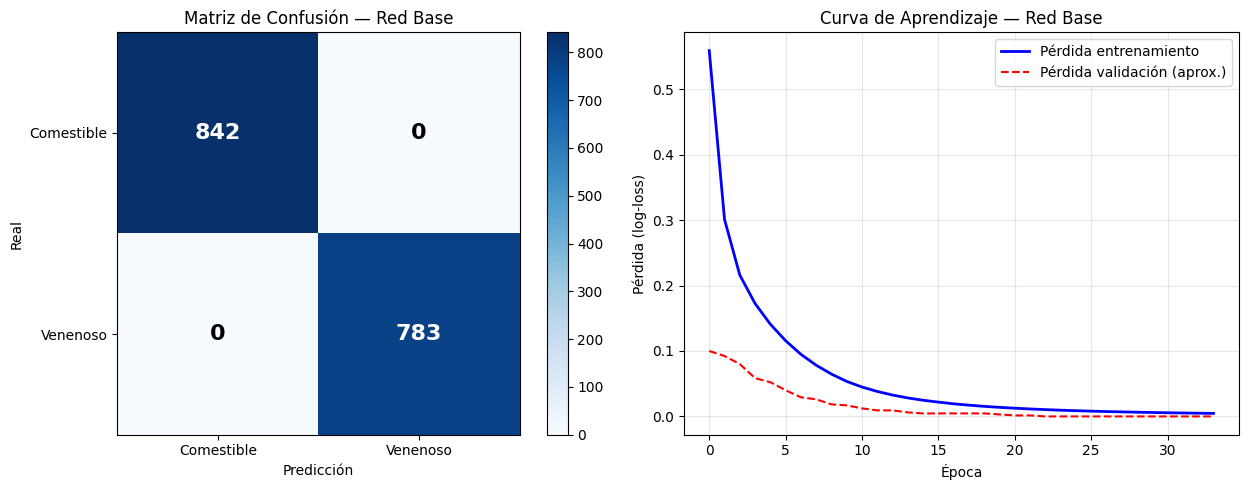

✓ Gráficos guardados


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Comestible', 'Venenoso'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['Comestible', 'Venenoso'])
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión — Red Base')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])

# ── Curva de pérdida durante el entrenamiento
axes[1].plot(modelo_base.loss_curve_, 'b-', lw=2, label='Pérdida entrenamiento')
if hasattr(modelo_base, 'validation_scores_') and modelo_base.validation_scores_:
    # convertir scores a pérdida aproximada
    val_loss = [1 - s for s in modelo_base.validation_scores_]
    axes[1].plot(val_loss, 'r--', lw=1.5, label='Pérdida validación (aprox.)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Pérdida (log-loss)')
axes[1].set_title('Curva de Aprendizaje — Red Base')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('red_base_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráficos guardados')

### Comparación de distintas arquitecturas manuales
Para mostrar que la arquitectura **sí importa** → motivación para usar el AG.

In [ ]:
# ── Probar varias arquitecturas manualmente ──────────────────
arquitecturas_prueba = [
    {'capas_ocultas': (16,),       'activacion': 'relu',     'label': '(16,) relu'},
    {'capas_ocultas': (64,),       'activacion': 'relu',     'label': '(64,) relu'},
    {'capas_ocultas': (100,),      'activacion': 'relu',     'label': '(100,) relu ← BASE'},
    {'capas_ocultas': (64, 32),    'activacion': 'relu',     'label': '(64,32) relu'},
    {'capas_ocultas': (64, 32),    'activacion': 'tanh',     'label': '(64,32) tanh'},
    {'capas_ocultas': (128, 64, 32),'activacion': 'relu',    'label': '(128,64,32) relu'},
]

print('Probando arquitecturas... (puede tomar ~1 minuto)')
resultados = []
for cfg in arquitecturas_prueba:
    acc = entrenar_y_evaluar(
        capas_ocultas = cfg['capas_ocultas'],
        activacion    = cfg['activacion'],
        learning_rate = 0.001,
        max_iter      = 200
    )
    resultados.append({'label': cfg['label'], 'accuracy': acc})
    print(f'  {cfg["label"]:30s} → {acc:.4f}')

res_df = pd.DataFrame(resultados).sort_values('accuracy', ascending=False)
print('\n✓ Listo')

Probando arquitecturas... (puede tomar ~1 minuto)
  (16,) relu                     → 0.9868
  (64,) relu                     → 0.9979
  (100,) relu ← BASE             → 0.9993
  (64,32) relu                   → 0.9985
  (64,32) tanh                   → 0.9986
  (128,64,32) relu               → 0.9998

✓ Listo


Se probaron distintas arquitecturas de redes neuronales variando capas y funciones de activación para comparar su rendimiento mediante validación cruzada. Todas lograron alta precisión, destacando la arquitectura (128,64,32) con relu como la mejor (99.98%), aunque la base ya mostraba resultados muy altos. Debido a que existen múltiples combinaciones posibles y pequeñas mejoras entre ellas, se utilizará un algoritmo genético (AG) para optimizar automáticamente los hiperparámetros y encontrar la mejor configuración de forma más eficiente.

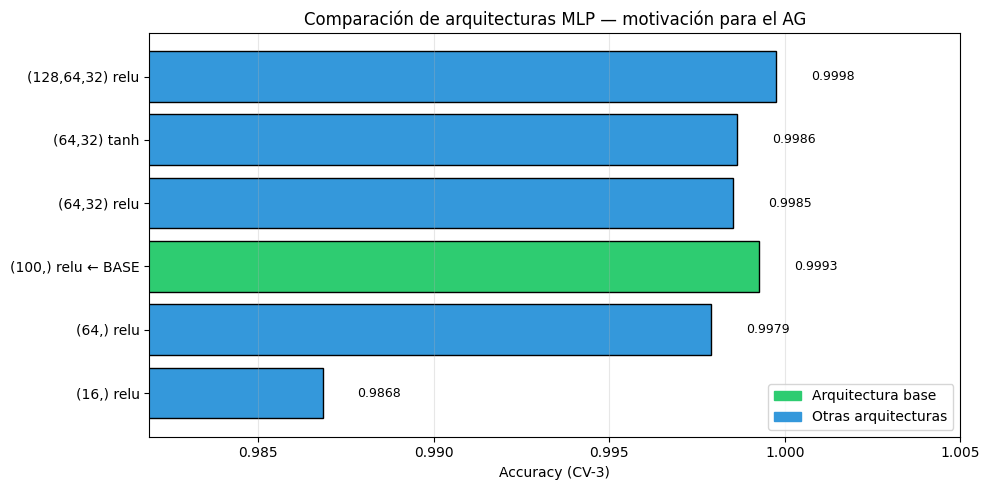

✓ Gráfico guardado


In [ ]:
# Visualización de comparación
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#2ecc71' if '← BASE' in r['label'] else '#3498db' for r in resultados]
bars = ax.barh(
    [r['label'] for r in resultados],
    [r['accuracy'] for r in resultados],
    color=colores, edgecolor='black'
)
for bar, r in zip(bars, resultados):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{r["accuracy"]:.4f}', va='center', fontsize=9)
ax.set_xlabel('Accuracy (CV-3)')
ax.set_title('Comparación de arquitecturas MLP — motivación para el AG')
ax.set_xlim([min(r['accuracy'] for r in resultados) * 0.995, 1.005])
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2ecc71', label='Arquitectura base'),
    Patch(color='#3498db', label='Otras arquitecturas')
], loc='lower right')

plt.tight_layout()
plt.savefig('comparacion_arquitecturas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfico guardado')

#Neuroevolution: Algoritmo Genético
## Dataset: Mushroom Classification (UCI / Kaggle)

---
### Responsabilidad de esta parte:
Este notebook **continúa directamente** el trabajo de la Persona 3.  
Asume que ya están definidas y ejecutadas en el mismo entorno:
- `X_norm` — features normalizadas (8124 × 22)
- `y` — etiquetas (0 = comestible, 1 = venenoso)
- `entrenar_y_evaluar(capas_ocultas, activacion, learning_rate, max_iter)` → accuracy
- `acc_base` — accuracy de la red base (línea de comparación)

**La Persona 4 NO toca la red neuronal.  
Solo decide QUÉ arquitectura probar — el AG llama a `entrenar_y_evaluar()` como caja negra.**

---
## Ciclo del Algoritmo Genético
| Paso | Qué hace |
|---|---|
| 1. Representación | Cromosoma = índices en listas de valores discretos |
| 2. Inicialización | Población aleatoria de arquitecturas |
| 3. Fitness | Llama a `entrenar_y_evaluar()` de Persona 3 |
| 4. Selección | Torneo de tamaño k |
| 5. Cruzamiento | Un punto de corte |
| 6. Mutación | Cambio aleatorio de un gen |
| 7. Terminación | N generaciones con elitismo |

---
## ⚙️ PASO 0 — Montar Drive y ejecutar el notebook de Persona 3

> **Instrucción:** Antes de correr cualquier celda de esta sección,  
> asegúrate de haber ejecutado **todo** el notebook de la Persona 3.  
> Deben estar disponibles en memoria: `X_norm`, `y`, `entrenar_y_evaluar`, `acc_base`.

In [ ]:
# Verificar que las variables de Persona 3 están disponibles
try:
    print(f'✓ X_norm disponible: {X_norm.shape}')
    print(f'✓ y disponible: {y.shape}')
    print(f'✓ acc_base: {acc_base:.4f}')
    print(f'✓ entrenar_y_evaluar: {entrenar_y_evaluar}')
    print('\n✅ Todo listo. Puedes continuar con el AG.')
except NameError as e:
    print(f'❌ Falta ejecutar el notebook de Persona 3 primero: {e}')

✓ X_norm disponible: (8124, 22)
✓ y disponible: (8124,)
✓ acc_base: 0.9993
✓ entrenar_y_evaluar: <function entrenar_y_evaluar at 0x795636f41940>

✅ Todo listo. Puedes continuar con el AG.


In [ ]:
# Librerías propias del AG (solo lógica evolutiva, sin ML)
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
print('✓ Librerías del AG cargadas')

✓ Librerías del AG cargadas


---
## PASO 1 — Representación del Cromosoma

Cada individuo del AG es un **cromosoma** que codifica una arquitectura de red neuronal.  
No guardamos los valores directamente, sino **índices** sobre listas de opciones:

```
cromosoma = [idx_capas, idx_n1, idx_n2, idx_activacion, idx_lr, idx_iter]
              ↓           ↓       ↓        ↓               ↓       ↓
ejemplo    = [  1,        2,      1,        0,              2,      1  ]
             = 2 capas,  64n,   32n,      relu,          0.01,   300 iter
```

La función `cromosoma_a_params()` traduce los índices a los parámetros reales que recibe `entrenar_y_evaluar()`.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 1. REPRESENTACIÓN — Espacio de búsqueda
# Cada gen es un índice en su lista de valores posibles
# ══════════════════════════════════════════════════════════════════

ESPACIO = {
    # Gen 0: número de capas ocultas
    'n_capas':    [1, 2, 3],
    # Gen 1: neuronas en capa 1
    'neuronas_1': [16, 32, 64, 128],
    # Gen 2: neuronas en capa 2 (solo se usa si n_capas >= 2)
    'neuronas_2': [8, 16, 32, 64],
    # Gen 3: neuronas en capa 3 (solo se usa si n_capas == 3)
    'neuronas_3': [8, 16, 32],
    # Gen 4: función de activación — mismas opciones que acepta MLPClassifier
    'activacion': ['relu', 'tanh', 'logistic'],
    # Gen 5: learning rate
    'lr':         [0.1, 0.01, 0.001, 0.0001],
    # Gen 6: épocas máximas
    'max_iter':   [100, 200, 300]
}

GENES = list(ESPACIO.keys())
N_GENES = len(GENES)

print(f'Número de genes por cromosoma: {N_GENES}')
print(f'Tamaño del espacio de búsqueda: {1}')
total = 1
for g in GENES:
    total *= len(ESPACIO[g])
    print(f'  {g}: {len(ESPACIO[g])} opciones → {ESPACIO[g]}')
print(f'\nTotal de combinaciones posibles: {total:,}')

Número de genes por cromosoma: 7
Tamaño del espacio de búsqueda: 1
  n_capas: 3 opciones → [1, 2, 3]
  neuronas_1: 4 opciones → [16, 32, 64, 128]
  neuronas_2: 4 opciones → [8, 16, 32, 64]
  neuronas_3: 3 opciones → [8, 16, 32]
  activacion: 3 opciones → ['relu', 'tanh', 'logistic']
  lr: 4 opciones → [0.1, 0.01, 0.001, 0.0001]
  max_iter: 3 opciones → [100, 200, 300]

Total de combinaciones posibles: 5,184


In [ ]:
def cromosoma_a_params(crom):

    n_capas    = ESPACIO['n_capas'][crom[0]]
    neuronas   = [
        ESPACIO['neuronas_1'][crom[1]],
        ESPACIO['neuronas_2'][crom[2]],
        ESPACIO['neuronas_3'][crom[3]]
    ]
    capas_ocultas = tuple(neuronas[:n_capas])

    return {
        'capas_ocultas': capas_ocultas,
        'activacion':    ESPACIO['activacion'][crom[4]],
        'learning_rate': ESPACIO['lr'][crom[5]],
        'max_iter':      ESPACIO['max_iter'][crom[6]]
    }

ejemplo = [1, 2, 1, 0, 0, 2, 1]
params  = cromosoma_a_params(ejemplo)
print('Cromosoma ejemplo:', ejemplo)
print('Parámetros reales:', params)
print('\n→ capas_ocultas se pasa directamente a entrenar_y_evaluar()')

Cromosoma ejemplo: [1, 2, 1, 0, 0, 2, 1]
Parámetros reales: {'capas_ocultas': (64, 16), 'activacion': 'relu', 'learning_rate': 0.001, 'max_iter': 200}

→ capas_ocultas se pasa directamente a entrenar_y_evaluar()


---
## PASO 2 — Inicialización de la Población

Se generan `TAM_POB` cromosomas aleatorios.  
Cada gen toma un índice válido al azar dentro de su lista de opciones.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 2. INICIALIZACIÓN
# ══════════════════════════════════════════════════════════════════

TAM_POB = 10

def crear_cromosoma():
    """Genera un cromosoma con índices aleatorios válidos."""
    return [random.randint(0, len(ESPACIO[g]) - 1) for g in GENES]

def crear_poblacion(tam):
    """Crea la población inicial."""
    return [crear_cromosoma() for _ in range(tam)]

poblacion = crear_poblacion(TAM_POB)

print(f'Población inicial: {TAM_POB} individuos')
print(f'\n{"#":<4} {"Cromosoma":<30} {"Arquitectura"}')
print('-' * 65)
for i, crom in enumerate(poblacion):
    p = cromosoma_a_params(crom)
    print(f'{i:<4} {str(crom):<30} capas={p["capas_ocultas"]} act={p["activacion"]} lr={p["learning_rate"]}')

Población inicial: 10 individuos

#    Cromosoma                      Arquitectura
-----------------------------------------------------------------
0    [2, 0, 0, 2, 1, 1, 0]          capas=(16, 8, 32) act=tanh lr=0.01
1    [0, 0, 0, 2, 1, 0, 0]          capas=(16,) act=tanh lr=0.1
2    [0, 1, 1, 2, 2, 0, 2]          capas=(32,) act=logistic lr=0.1
3    [0, 3, 1, 1, 2, 2, 0]          capas=(128,) act=logistic lr=0.001
4    [0, 3, 2, 1, 0, 1, 1]          capas=(128,) act=relu lr=0.01
5    [0, 0, 3, 0, 1, 2, 2]          capas=(16,) act=tanh lr=0.001
6    [1, 0, 3, 2, 0, 3, 0]          capas=(16, 64) act=relu lr=0.0001
7    [2, 2, 2, 2, 0, 0, 0]          capas=(64, 32, 32) act=relu lr=0.1
8    [2, 1, 2, 0, 0, 0, 1]          capas=(32, 32, 8) act=relu lr=0.1
9    [1, 3, 2, 0, 1, 2, 0]          capas=(128, 32) act=tanh lr=0.001


---
## PASO 3 — Función de Aptitud (Fitness)

El AG no sabe nada sobre redes neuronales.  
Solo llama a `entrenar_y_evaluar()` (definida por Persona 3) y recibe un número.

```
cromosoma → cromosoma_a_params() → entrenar_y_evaluar() → accuracy (float)
                                   ↑
                           [caja negra de Persona 3]
```

Se usa un caché `dict` para no re-evaluar cromosomas idénticos (ahorra tiempo).

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 3. FUNCIÓN DE APTITUD (FITNESS)
# ══════════════════════════════════════════════════════════════════

_cache_fitness = {}

def fitness(cromosoma):

    key = tuple(cromosoma)
    if key in _cache_fitness:
        return _cache_fitness[key]

    params = cromosoma_a_params(cromosoma)

    acc = entrenar_y_evaluar(
        capas_ocultas  = params['capas_ocultas'],
        activacion     = params['activacion'],
        learning_rate  = params['learning_rate'],
        max_iter       = params['max_iter']
    )

    _cache_fitness[key] = acc
    return acc

print('Evaluando primer individuo...')
p0     = cromosoma_a_params(poblacion[0])
fit_0  = fitness(poblacion[0])
print(f'Cromosoma : {poblacion[0]}')
print(f'Arquitectura: {p0}')
print(f'Fitness (accuracy CV-3): {fit_0:.4f}')

Evaluando primer individuo...
Cromosoma : [2, 0, 0, 2, 1, 1, 0]
Arquitectura: {'capas_ocultas': (16, 8, 32), 'activacion': 'tanh', 'learning_rate': 0.01, 'max_iter': 100}
Fitness (accuracy CV-3): 0.9983


---
## PASO 4 — Selección por Torneo

Se eligen `k` individuos al azar de la población y gana el de mayor fitness.  
Se repite 2 veces para obtener los dos padres de cada hijo.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 4. SELECCIÓN — Torneo de tamaño k
# ══════════════════════════════════════════════════════════════════

def seleccion_torneo(poblacion, fitnesses, k=3):

    candidatos = random.sample(range(len(poblacion)), min(k, len(poblacion)))
    ganador    = max(candidatos, key=lambda i: fitnesses[i])
    return poblacion[ganador][:]

fits_demo = [0.91, 0.97, 0.88, 0.95, 0.93]
pob_demo  = [[i]*N_GENES for i in range(5)]
ganador   = seleccion_torneo(pob_demo, fits_demo, k=3)
print('Torneo demo con fitnesses:', fits_demo)
print('Ganador del torneo:', ganador)

Torneo demo con fitnesses: [0.91, 0.97, 0.88, 0.95, 0.93]
Ganador del torneo: [4, 4, 4, 4, 4, 4, 4]


---
## PASO 5 — Cruzamiento (Un punto de corte)

Dos padres intercambian genes a partir de un punto aleatorio.  
Resultado: dos hijos que heredan partes de cada padre.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 5. CRUZAMIENTO — Un punto de corte
# ══════════════════════════════════════════════════════════════════

def cruzamiento(padre1, padre2, prob_cruce=0.85):

    if random.random() < prob_cruce:
        punto  = random.randint(1, N_GENES - 1)
        hijo1  = padre1[:punto] + padre2[punto:]
        hijo2  = padre2[:punto] + padre1[punto:]
    else:
        hijo1 = padre1[:]
        hijo2 = padre2[:]
    return hijo1, hijo2

p1 = [0, 3, 1, 0, 0, 2, 1]   # padre 1
p2 = [2, 1, 3, 2, 2, 0, 2]   # padre 2
h1, h2 = cruzamiento(p1, p2)
print('Padre 1:', p1)
print('Padre 2:', p2)
print('Hijo  1:', h1)
print('Hijo  2:', h2)
print('\nGenes de cada hijo:')
print('  Hijo1 arquitectura:', cromosoma_a_params(h1)['capas_ocultas'],
      'act:', cromosoma_a_params(h1)['activacion'])
print('  Hijo2 arquitectura:', cromosoma_a_params(h2)['capas_ocultas'],
      'act:', cromosoma_a_params(h2)['activacion'])

Padre 1: [0, 3, 1, 0, 0, 2, 1]
Padre 2: [2, 1, 3, 2, 2, 0, 2]
Hijo  1: [0, 3, 1, 0, 0, 0, 2]
Hijo  2: [2, 1, 3, 2, 2, 2, 1]

Genes de cada hijo:
  Hijo1 arquitectura: (128,) act: relu
  Hijo2 arquitectura: (32, 64, 32) act: logistic


---
## PASO 6 — Mutación (Cambio de gen)

Con probabilidad `prob_mut` por gen, se reemplaza el índice actual  
por otro válido al azar.  
Mantiene diversidad genética y evita convergencia prematura.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6. MUTACIÓN — Cambio aleatorio de un gen
# ══════════════════════════════════════════════════════════════════

def mutacion(cromosoma, prob_mut=0.15):

    crom = cromosoma[:]
    mutaciones = []
    for i, g in enumerate(GENES):
        if random.random() < prob_mut:
            valor_anterior = crom[i]
            crom[i] = random.randint(0, len(ESPACIO[g]) - 1)
            mutaciones.append(f'{g}: idx {valor_anterior}→{crom[i]}')
    return crom, mutaciones

def mutar(cromosoma, prob_mut=0.15):
    """Versión simplificada que solo retorna el cromosoma."""
    crom = cromosoma[:]
    for i, g in enumerate(GENES):
        if random.random() < prob_mut:
            crom[i] = random.randint(0, len(ESPACIO[g]) - 1)
    return crom

original = [1, 2, 1, 0, 0, 2, 1]
mutado, cambios = mutacion(original, prob_mut=0.5)
print('Original:', original)
print('Mutado:  ', mutado)
print('Cambios: ', cambios if cambios else 'ninguno')

Original: [1, 2, 1, 0, 0, 2, 1]
Mutado:   [1, 3, 1, 0, 0, 2, 0]
Cambios:  ['neuronas_1: idx 2→3', 'neuronas_2: idx 1→1', 'max_iter: idx 1→0']


---
## PASO 7 — Ciclo Evolutivo + Terminación

El AG repite por `N_GENERACIONES` veces:
1. Evaluar toda la población → lista de fitnesses
2. Guardar el mejor (elitismo)
3. Generar nueva población: selección → cruzamiento → mutación
4. Al terminar: reportar la mejor arquitectura encontrada

**Terminación:** número fijo de generaciones.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 7. CICLO EVOLUTIVO COMPLETO
# ══════════════════════════════════════════════════════════════════

N_GENERACIONES = 8

historial_mejor = []
historial_prom  = []
mejor_global    = None
mejor_fit_global = -1

print('=' * 70)
print(f'  AG Neuroevolution — {N_GENERACIONES} generaciones × {TAM_POB} individuos')
print(f'  Línea base (Persona 3): acc_base = {acc_base:.4f}')
print('=' * 70)

for gen in range(N_GENERACIONES):
    # ── EVALUACIÓN ─────────────────────────────────────────────
    fitnesses = []
    for i, crom in enumerate(poblacion):
        f = fitness(crom)
        fitnesses.append(f)

    # ── ESTADÍSTICAS ───────────────────────────────────────────
    mejor_gen_idx = int(np.argmax(fitnesses))
    mejor_gen_fit = fitnesses[mejor_gen_idx]
    prom_gen      = np.mean(fitnesses)

    if mejor_gen_fit > mejor_fit_global:
        mejor_fit_global = mejor_gen_fit
        mejor_global     = poblacion[mejor_gen_idx][:]

    historial_mejor.append(mejor_fit_global)
    historial_prom.append(prom_gen)

    params_mejor = cromosoma_a_params(mejor_global)
    print(f'Gen {gen+1:02d} | Mejor: {mejor_fit_global:.4f} | '
          f'Prom: {prom_gen:.4f} | '
          f'Arq: {params_mejor["capas_ocultas"]} {params_mejor["activacion"]} '
          f'lr={params_mejor["learning_rate"]}')

    # ── NUEVA GENERACIÓN ───────────────────────────────────────
    nueva_pob = [mejor_global[:]]   # elitismo: el mejor pasa directo

    while len(nueva_pob) < TAM_POB:
        # Selección: dos padres por torneo
        padre1 = seleccion_torneo(poblacion, fitnesses, k=3)
        padre2 = seleccion_torneo(poblacion, fitnesses, k=3)

        # Cruzamiento
        hijo1, hijo2 = cruzamiento(padre1, padre2)

        # Mutación
        hijo1 = mutar(hijo1, prob_mut=0.15)
        hijo2 = mutar(hijo2, prob_mut=0.15)

        nueva_pob.append(hijo1)
        if len(nueva_pob) < TAM_POB:
            nueva_pob.append(hijo2)

    poblacion = nueva_pob

print('\n✅ Algoritmo Genético terminado')
print(f'   Evaluaciones totales: {len(_cache_fitness)} configuraciones únicas')

  AG Neuroevolution — 8 generaciones × 10 individuos
  Línea base (Persona 3): acc_base = 0.9993
Gen 01 | Mejor: 0.9998 | Prom: 0.9963 | Arq: (64, 32, 32) relu lr=0.1
Gen 02 | Mejor: 1.0000 | Prom: 0.9924 | Arq: (128,) tanh lr=0.1
Gen 03 | Mejor: 1.0000 | Prom: 0.9968 | Arq: (128,) tanh lr=0.1
Gen 04 | Mejor: 1.0000 | Prom: 0.9994 | Arq: (128,) tanh lr=0.1
Gen 05 | Mejor: 1.0000 | Prom: 0.9996 | Arq: (128,) tanh lr=0.1
Gen 06 | Mejor: 1.0000 | Prom: 0.9990 | Arq: (128,) tanh lr=0.1
Gen 07 | Mejor: 1.0000 | Prom: 0.9999 | Arq: (128,) tanh lr=0.1
Gen 08 | Mejor: 1.0000 | Prom: 0.9966 | Arq: (128,) tanh lr=0.1

✅ Algoritmo Genético terminado
   Evaluaciones totales: 49 configuraciones únicas


---
## RESULTADOS

In [ ]:
# ── Mejor arquitectura encontrada ────────────────────────────────
mejor_params = cromosoma_a_params(mejor_global)

print('\n' + '═'*55)
print('  🏆 MEJOR ARQUITECTURA ENCONTRADA POR EL AG')
print('═'*55)
print(f'  Cromosoma:       {mejor_global}')
print(f'  Capas ocultas:   {mejor_params["capas_ocultas"]}')
print(f'  Activación:      {mejor_params["activacion"]}')
print(f'  Learning rate:   {mejor_params["learning_rate"]}')
print(f'  Épocas máx.:     {mejor_params["max_iter"]}')
print(f'  Accuracy CV-3:   {mejor_fit_global:.4f} ({mejor_fit_global*100:.2f}%)')
print('─'*55)
print(f'  Red base (P3):   {acc_base:.4f} ({acc_base*100:.2f}%)')
mejora = (mejor_fit_global - acc_base) * 100
print(f'  Diferencia:      {mejora:+.4f}%')
print('═'*55)


═══════════════════════════════════════════════════════
  🏆 MEJOR ARQUITECTURA ENCONTRADA POR EL AG
═══════════════════════════════════════════════════════
  Cromosoma:       [0, 3, 2, 1, 1, 0, 0]
  Capas ocultas:   (128,)
  Activación:      tanh
  Learning rate:   0.1
  Épocas máx.:     100
  Accuracy CV-3:   1.0000 (100.00%)
───────────────────────────────────────────────────────
  Red base (P3):   0.9993 (99.93%)
  Diferencia:      +0.0739%
═══════════════════════════════════════════════════════


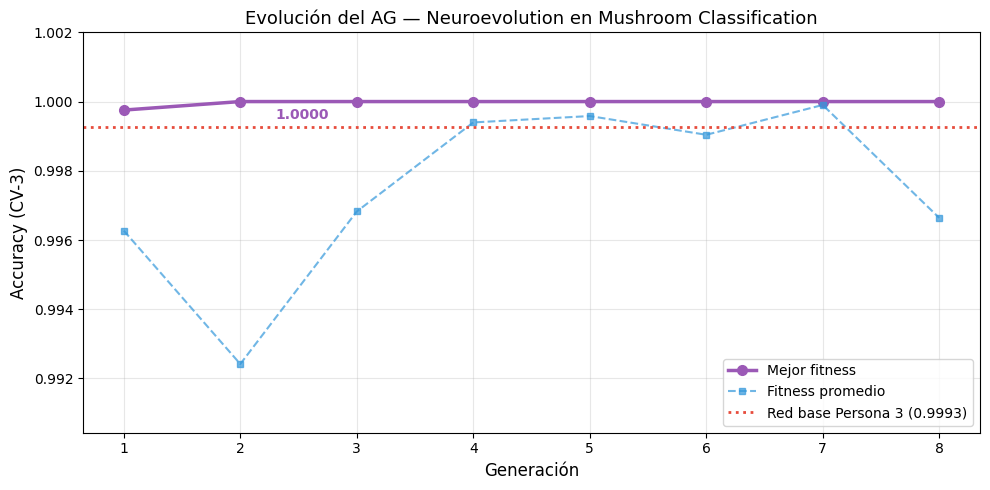

✓ Gráfico guardado


In [ ]:
# ── Gráfica de evolución ──────────────────────────────────────────
generaciones = range(1, N_GENERACIONES + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(generaciones, historial_mejor, 'o-',
        color='#9b59b6', linewidth=2.5, markersize=7, label='Mejor fitness')
ax.plot(generaciones, historial_prom, 's--',
        color='#3498db', linewidth=1.5, markersize=5, label='Fitness promedio', alpha=0.7)
ax.axhline(acc_base, color='#e74c3c', linestyle=':', linewidth=2,
           label=f'Red base Persona 3 ({acc_base:.4f})')

ax.set_xlabel('Generación', fontsize=12)
ax.set_ylabel('Accuracy (CV-3)', fontsize=12)
ax.set_title('Evolución del AG — Neuroevolution en Mushroom Classification', fontsize=13)
ax.set_xticks(list(generaciones))
ax.set_ylim([min(historial_prom) * 0.998, 1.002])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Anotar el mejor punto
mejor_gen_num = int(np.argmax(historial_mejor)) + 1
ax.annotate(f'{mejor_fit_global:.4f}',
            xy=(mejor_gen_num, mejor_fit_global),
            xytext=(mejor_gen_num + 0.3, mejor_fit_global - 0.0005),
            fontsize=10, color='#9b59b6', fontweight='bold')

plt.tight_layout()
plt.savefig('evolucion_ag_neuroevolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfico guardado')

In [ ]:
# ── Historial completo de búsqueda ────────────────────────────────
print(f'\nTodas las arquitecturas evaluadas ({len(_cache_fitness)} únicas):')
print(f'{"#":<4} {"Capas":<18} {"Act":<10} {"LR":<8} {"Iter":<6} {"Accuracy"}')
print('-' * 60)

evaluadas = sorted(
    [(list(k), v) for k, v in _cache_fitness.items()],
    key=lambda x: x[1],
    reverse=True
)
for i, (crom, acc) in enumerate(evaluadas[:15]):  # top 15
    p = cromosoma_a_params(crom)
    marca = ' ← MEJOR' if i == 0 else ''
    print(f'{i+1:<4} {str(p["capas_ocultas"]):<18} '
          f'{p["activacion"]:<10} {p["learning_rate"]:<8} '
          f'{p["max_iter"]:<6} {acc:.4f}{marca}')


Todas las arquitecturas evaluadas (49 únicas):
#    Capas              Act        LR       Iter   Accuracy
------------------------------------------------------------
1    (128,)             tanh       0.1      100    1.0000 ← MEJOR
2    (128,)             tanh       0.1      100    1.0000
3    (128,)             relu       0.1      100    1.0000
4    (128,)             relu       0.1      100    1.0000
5    (128,)             relu       0.1      100    1.0000
6    (128,)             tanh       0.1      100    1.0000
7    (128,)             relu       0.1      100    1.0000
8    (128,)             relu       0.1      100    1.0000
9    (128,)             tanh       0.1      100    1.0000
10   (128,)             relu       0.1      100    1.0000
11   (64, 32, 32)       relu       0.1      100    0.9998
12   (64, 32, 32)       relu       0.1      300    0.9998
13   (32,)              logistic   0.1      300    0.9996
14   (128, 16, 32)      logistic   0.1      100    0.9996
15   (128, 

---
## RESUMEN

| Componente del AG | Implementación |
|---|---|
| **Representación** | Cromosoma de 7 índices → traduce a parámetros reales con `cromosoma_a_params()` |
| **Inicialización** | `crear_poblacion()` — aleatorio uniforme en el espacio de búsqueda |
| **Fitness** | `fitness()` llama a `entrenar_y_evaluar()` de Persona 3 (caja negra) |
| **Selección** | `seleccion_torneo()` — k=3 candidatos, gana el mejor |
| **Cruzamiento** | `cruzamiento()` — un punto de corte aleatorio |
| **Mutación** | `mutar()` — prob=0.15 por gen, nuevo índice aleatorio |
| **Terminación** | N generaciones fijas + elitismo (el mejor siempre pasa) |

